# vtpdetect


In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
The CIAO setup for this window has changed from
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3
To:
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 578
download_chandra_obsid 578 
chandra_repro 578 out=`pwd` clob+


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      10 Kb  ####################          < 1 s  1811.1 kb/s
  oif      fits       25 Kb  ####################          < 1 s  3996.8 kb/s
  vv       pdf        46 Kb  ####################          < 1 s  6180.5 kb/s
  cntr_img fits      129 Kb  ####################          < 1 s  13889.5 kb/s
  cntr_img jpg       575 Kb  ####################          < 1 s  33341.4 kb/s
  evt2     fits       10 Mb  ####################          < 1 s  74743.2 kb/s
  full_img fits       76 Kb  ####################          < 1 s  7691.6 kb/s
  full_img jpg        69 Kb  ####################          < 1 s  7323.5 kb/s
  src2     fits       13 Kb  ####################          < 1 s  2316.1 kb/s
  src_img  jpg        71 Kb  ####################          < 1 s  7859.4 kb/s
  bpix     fits       19 Kb  ####################          <

In [3]:
dmcopy "acisf00578_repro_fov1.fits[ccd_id=7]" s3.fov clob+
dmcopy "acisf00578_repro_evt2.fits[ccd_id=7,energy=500:7000,sky=region(s3.fov)]" s3_evt2.fits clob+


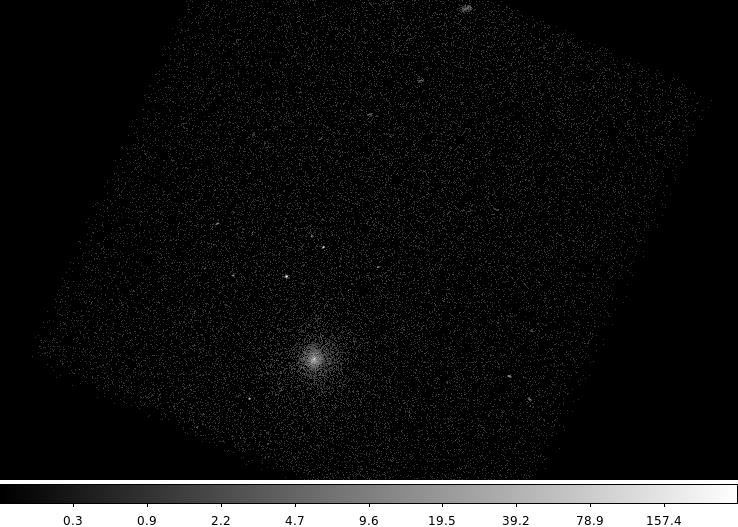

In [4]:
ds9 s3_evt2.fits \
  -pan to 4200 4350 physical \
  -bin factor 2 \
  -scale log \
  -saveimage png ds9_01.png &
sleep 10
xpaset -p ds9 quit

display < ds9_01.png

## Run vtpdetect

In [5]:
punlearn vtpdetect
pset vtpdetect infile=s3_evt2.fits
pset vtpdetect outfile=s3_src.fits
vtpdetect mode=h clob+


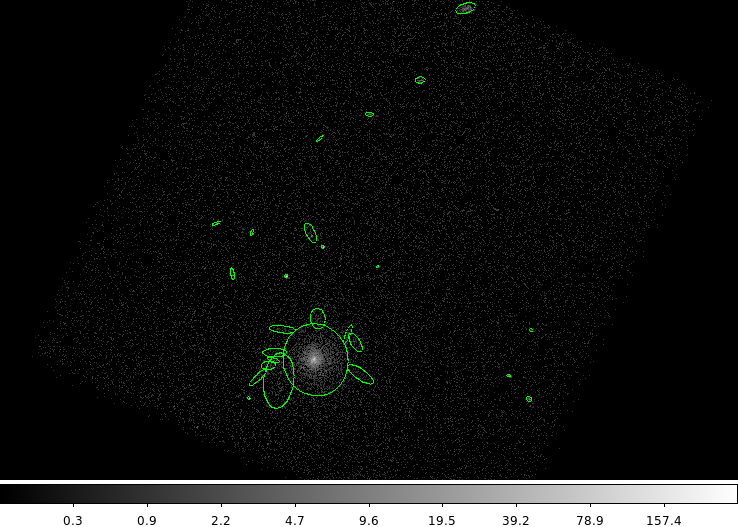

In [6]:
ds9 s3_evt2.fits \
  -pan to 4200 4350 physical \
  -bin factor 2 \
  -scale log \
  -region s3_src.fits \
  -saveimage png ds9_02.png &
sleep 10
xpaset -p ds9 quit

display < ds9_02.png

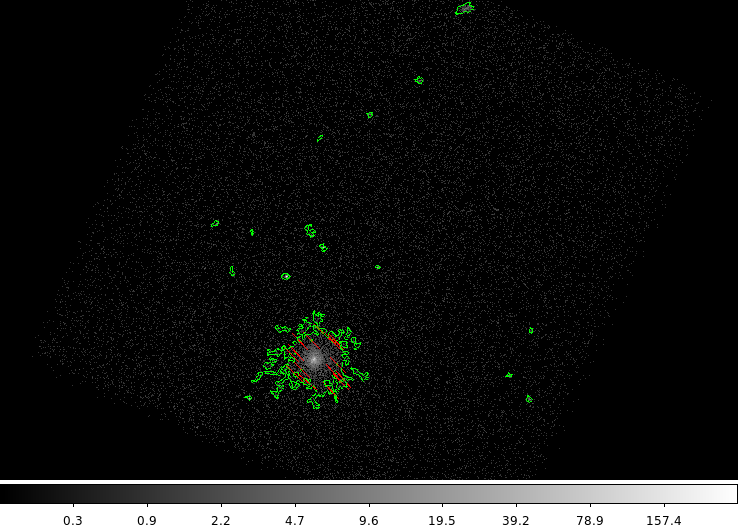

In [7]:
ds9 s3_evt2.fits \
  -pan to 4200 4350 physical \
  -bin factor 2 \
  -scale log \
  -region s3_src.fits"[src_region]" \
  -saveimage png ds9_03.png &
sleep 10
xpaset -p ds9 quit

display < ds9_03.png

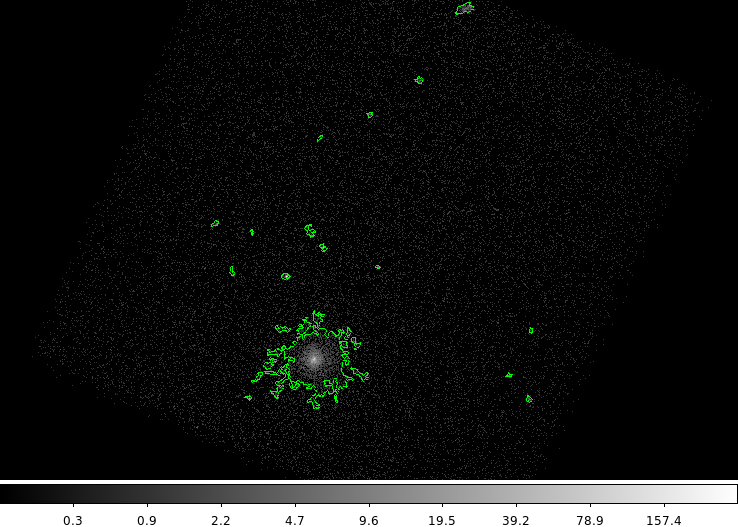

In [8]:
dmcopy "s3_src.fits[src_region][shape=Polygon]" s3_src_include_only.fits clob+

ds9 s3_evt2.fits \
  -pan to 4200 4350 physical \
  -bin factor 2 \
  -scale log \
  -region s3_src_include_only.fits"[src_region]" \
  -saveimage png ds9_04.png &
sleep 10
xpaset -p ds9 quit

display < ds9_04.png

## Inc exposure map

In [9]:
fluximage s3_evt2.fits s3 clob+ bin=2

Running fluximage
Version: 12 September 2016

Using CSC ACIS broad science energy band.
Aspect solution pcadf052378346N003_asol1.fits found.
Bad-pixel file acisf00578_repro_bpix1.fits found.
Mask file acisf00578_000N003_msk1.fits found.

The output images will have 695 by 695 pixels, pixel size of 0.984 arcsec,
    and cover x=3506.5:4896.5:2,y=3676.5:5066.5:2.

Running tasks in parallel with 4 processors.
Creating aspect histogram for obsid 578
Creating instrument map for obsid 578
Creating exposure map for obsid 578
Thresholding data for obsid 578
Exposure-correcting image for obsid 578

The following files were created:

 The clipped counts image is:
     s3_broad_thresh.img

 The clipped exposure map is:
     s3_broad_thresh.expmap

 The exposure-corrected image is:
     s3_broad_flux.img



In [10]:
pset vtpdetect expfile=s3_broad_thresh.expmap
pset vtpdetect outfile=s3_src_with_exp.fits
vtpdetect mode=h clob+


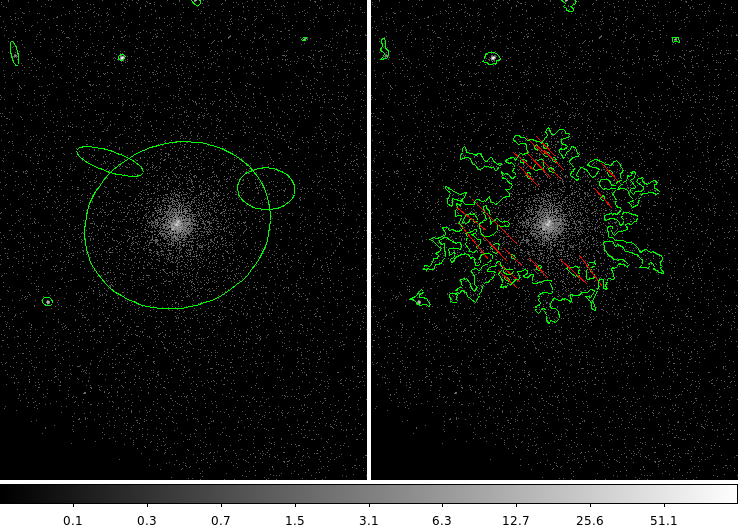

In [11]:
ds9 s3_evt2.fits \
  -bin factor 1 \
  -zoom 1 \
  -scale log \
  -region s3_src_with_exp.fits \
  s3_evt2.fits \
  -scale log \
  -region s3_src_with_exp.fits"[src_region]" \
  -saveimage png ds9_05.png &
sleep 10
xpaset -p ds9 quit

display < ds9_05.png

# Cleanup

In [ ]:
/bin/rm -rf 578 
/bin/rm -f acisf* pcadf* 